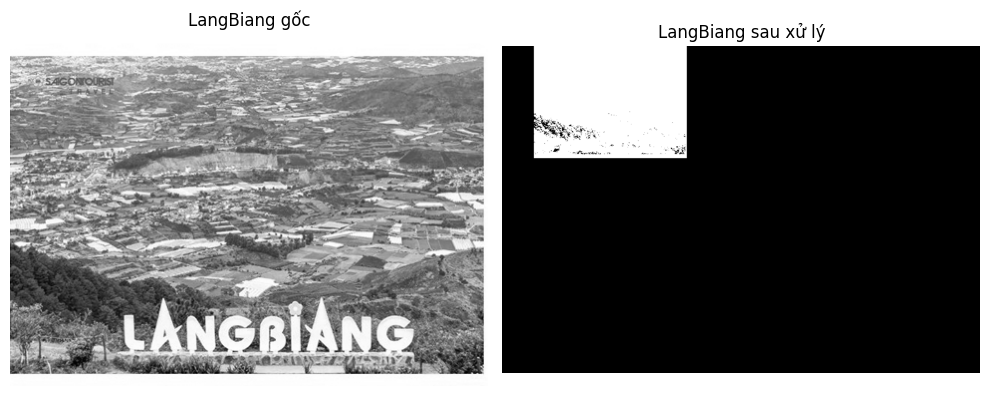

In [91]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# B1: Đọc ảnh và chuyển sang ảnh xám
img = cv2.imread('exercise/dalat.jpg')
if img is None:
    raise FileNotFoundError("Không tìm thấy ảnh 'dalat.jpg'.")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# B2: Chọn vùng LangBiang
roi = gray[0:355, 20:500]  # Chiều cao 355, chiều ngang 480

# B3: Áp dụng phân ngưỡng Otsu * 0.3
otsu_thresh, _ = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
threshold_val = 0.3 * otsu_thresh
_, binary = cv2.threshold(roi, threshold_val, 255, cv2.THRESH_BINARY)

# B4: Tịnh tiến vùng chọn sang phải 100px
translated = np.zeros_like(gray)
h, w = binary.shape
x_offset = 100
y_offset = 0

# Dán vùng sau khi tịnh tiến
if y_offset + h <= translated.shape[0] and x_offset + w <= translated.shape[1]:
    translated[y_offset:y_offset + h, x_offset:x_offset + w] = binary
else:
    raise ValueError("Tịnh tiến vượt quá kích thước ảnh! Hãy giảm offset hoặc vùng chọn.")

# B5: Lưu ảnh kết quả
cv2.imwrite("lang_biang.jpg", translated)

# B6: Hiển thị ảnh gốc vùng chọn và ảnh sau xử lý
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi, cmap='gray')
plt.title("LangBiang gốc")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(translated, cmap='gray')
plt.title("LangBiang sau xử lý")
plt.axis('off')

plt.tight_layout()
plt.show()




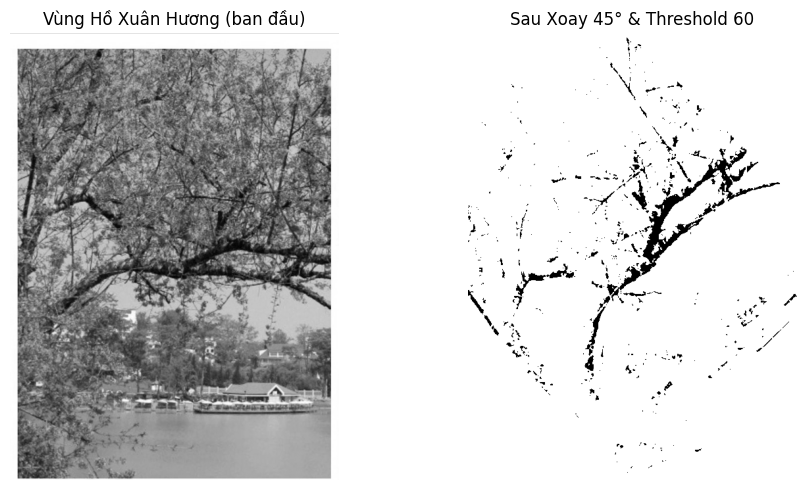

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# B1: Đọc ảnh
img = cv2.imread('exercise/dalat.jpg')
if img is None:
    raise FileNotFoundError("Không tìm thấy ảnh 'dalat.jpg'.")

# B2: Chuyển sang ảnh xám
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# B3: Vùng chọn Hồ Xuân Hương (rộng + cao như bạn yêu cầu)
roi = gray[0:680, 500:1000]  

# B4: Xoay 45 độ quanh tâm vùng chọn
(h, w) = roi.shape
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(roi, M, (w, h), borderValue=255)

# B5: Threshold với ngưỡng 60
_, thresh = cv2.threshold(rotated, 60, 255, cv2.THRESH_BINARY)

# B6: Lưu ảnh kết quả
cv2.imwrite('ho_xuan_huong.jpg', thresh)

# B7: Hiển thị ảnh trước & sau xử lý
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi, cmap='gray')
plt.title("Vùng Hồ Xuân Hương (ban đầu)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(thresh, cmap='gray')
plt.title("Sau Xoay 45° & Threshold 60")
plt.axis("off")

plt.tight_layout()
plt.show()



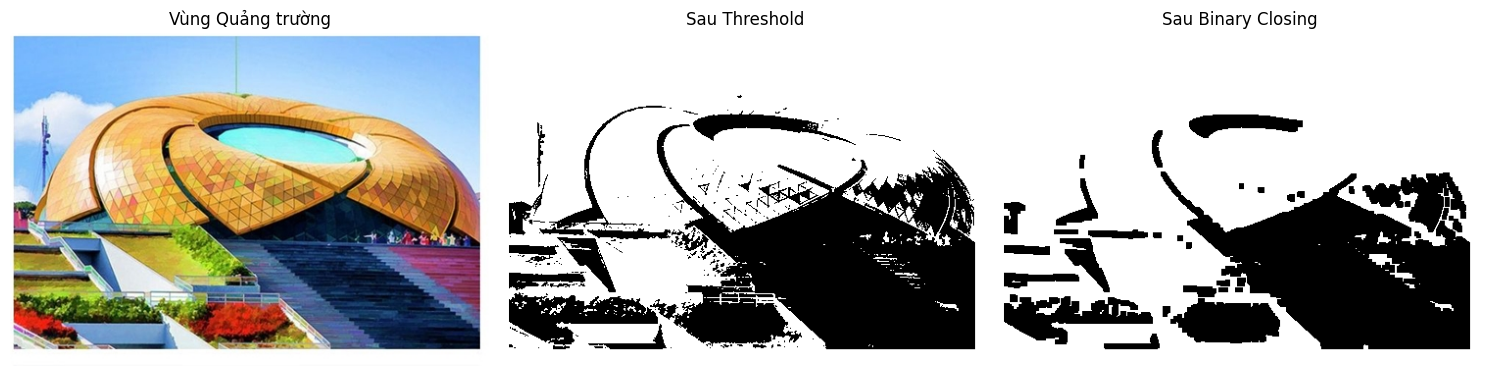

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh gốc
img = cv2.imread('exercise/dalat.jpg')
if img is None:
    raise FileNotFoundError("Không tìm thấy ảnh 'dalat.jpg'.")

# B1: Tọa độ vùng chọn
x, y, w, h = 1000, 20, 490, 340
roi = img[y:y+h, x:x+w]

# B2: Grayscale
gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

# B3: Threshold
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# B4: Closing
kernel = np.ones((5, 5), np.uint8)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# B5: Lưu kết quả
cv2.imwrite('quan_truong_lam_vien.jpg', closed)

# ✅ B6: Hiển thị ảnh
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("Vùng Quảng trường")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary, cmap='gray')
plt.title("Sau Threshold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(closed, cmap='gray')
plt.title("Sau Binary Closing")
plt.axis("off")

plt.tight_layout()
plt.show()


